In [3]:
# ==========================================
# CÉLULA 1: SETUP E CARREGAMENTO
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Carregando o nosso dataset de features blindado
print("Carregando o Dataset de Machine Learning...")
df_ml = pd.read_csv('dataset_features_ml.csv')

print(f"Total de amostras prontas para o modelo: {len(df_ml)}")
display(df_ml.head())

Carregando o Dataset de Machine Learning...
Total de amostras prontas para o modelo: 52664


,ID_Trem,Ciclo,Degradacao_Atual,Velocidade_Desgaste,Vibracao_Posicao,RUL_Alvo,Grupo
0,1,1479,6.0,6.0,0.516398,1120,Validação
1,1,1480,6.0,6.0,0.516398,1119,Validação
2,1,1481,6.0,6.0,0.527046,1118,Validação
3,1,1482,6.0,6.0,0.527046,1117,Validação
4,1,1483,6.0,6.0,0.527046,1116,Validação


In [4]:
# ==========================================
# CÉLULA 2: MÉTRICA OFICIAL DE AVALIAÇÃO
# ==========================================
def calcular_score_phme2026(y_true, y_pred, alpha=2.0):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    n = len(y_true)
    epsilon = 1e-10 
    
    rmse_bruto = np.sqrt(np.mean((y_true - y_pred)**2))
    erro_relativo = np.abs(y_true - y_pred) / (y_true + epsilon)
    precision_bruto = 100 * np.mean(erro_relativo <= 0.1)
    
    erros_acima_20 = erro_relativo > 0.2
    if np.any(erros_acima_20):
        t_alpha = np.argmax(erros_acima_20)
    else:
        t_alpha = n 
        
    t_eof = n
    ph_norm = (t_eof - t_alpha) / t_eof
    
    a = 4443.76
    b = 1.53
    c = 4443.76
    d = 0.0
    
    def normalizar(m):
        return (a / (m**b + c)) + d
    
    rmse_norm = normalizar(rmse_bruto)
    precision_norm = normalizar(100.0 - precision_bruto)
    
    score_final = (rmse_norm + precision_norm + (alpha * ph_norm)) / (2 + alpha)
    
    return score_final, rmse_bruto, precision_bruto, ph_norm
    
print("Função de Score carregada com sucesso!")

Função de Score carregada com sucesso!


In [5]:
# ==========================================
# CÉLULA 3: SPLIT DE DADOS (X e Y)
# ==========================================
# Separando os DataFrames físicos
df_treino = df_ml[df_ml['Grupo'] == 'Treino'].copy()
df_val = df_ml[df_ml['Grupo'] == 'Validação'].copy()

# Definindo quem são as Features (X) e quem é o Alvo (Y)
# Não podemos usar ID_Trem, Ciclo e Grupo para treinar, senão o modelo "rouba"
features = ['Degradacao_Atual', 'Velocidade_Desgaste', 'Vibracao_Posicao']

X_treino = df_treino[features]
y_treino = df_treino['RUL_Alvo']

X_val = df_val[features]
y_val = df_val['RUL_Alvo']

print(f"Tamanho do Treino: {len(X_treino)} ciclos (Viagens)")
print(f"Tamanho da Validação: {len(X_val)} ciclos (Viagens)")

Tamanho do Treino: 33445 ciclos (Viagens)
Tamanho da Validação: 10218 ciclos (Viagens)


In [6]:
# ==========================================
# CÉLULA 4: TREINAMENTO DA INTELIGÊNCIA ARTIFICIAL
# ==========================================
print("Iniciando o treinamento da Random Forest...")

# max_depth=10 evita que o modelo decore os dados (overfitting)
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# A Mágica acontece aqui:
modelo_rf.fit(X_treino, y_treino)

print("Treinamento concluído com sucesso!")

Iniciando o treinamento da Random Forest...
Treinamento concluído com sucesso!


In [7]:
# ==========================================
# CÉLULA 5: PREVISÃO E CÁLCULO DA NOTA OFICIAL
# ==========================================
trens_validacao = df_val['ID_Trem'].unique()

notas_score = []
notas_rmse = []

print("--- RESULTADOS NA VALIDAÇÃO ---")

for trem in trens_validacao:
    # Pega apenas os dados daquele trem específico, em ordem cronológica
    df_trem_atual = df_val[df_val['ID_Trem'] == trem].sort_values(by='Ciclo')
    
    X_trem = df_trem_atual[features]
    y_real = df_trem_atual['RUL_Alvo'].values
    
    # O modelo prevê o RUL de todos os instantes do trem
    y_previsto = modelo_rf.predict(X_trem)
    
    # Aplica a sua função oficial de Score
    score, rmse, precisao, ph = calcular_score_phme2026(y_real, y_previsto)
    
    notas_score.append(score)
    notas_rmse.append(rmse)
    
    print(f"Train_{trem:02d} | Score Oficial: {score:.4f} | RMSE: {rmse:.0f} | Precisão: {precisao:.1f}%")

# Calculando a média final do grupo
score_medio = np.mean(notas_score)
rmse_medio = np.mean(notas_rmse)

print("\n" + "="*40)
print(f" SCORE MÉDIO FINAL (BASELINE): {score_medio:.4f}")
print(f" RMSE MÉDIO FINAL: {rmse_medio:.0f} viagens de erro")
print("="*40)

--- RESULTADOS NA VALIDAÇÃO ---
Train_01 | Score Oficial: 0.6942 | RMSE: 806 | Precisão: 20.2%
Train_12 | Score Oficial: 0.7954 | RMSE: 346 | Precisão: 8.1%
Train_13 | Score Oficial: 0.8191 | RMSE: 271 | Precisão: 9.8%
Train_20 | Score Oficial: 0.7450 | RMSE: 657 | Precisão: 2.8%
Train_21 | Score Oficial: 0.7908 | RMSE: 263 | Precisão: 8.9%
Train_27 | Score Oficial: 0.8601 | RMSE: 193 | Precisão: 23.5%
Train_28 | Score Oficial: 0.7395 | RMSE: 708 | Precisão: 0.4%
Train_46 | Score Oficial: 0.8606 | RMSE: 196 | Precisão: 26.9%
Train_48 | Score Oficial: 0.7894 | RMSE: 313 | Precisão: 6.6%

 SCORE MÉDIO FINAL (BASELINE): 0.7882
 RMSE MÉDIO FINAL: 417 viagens de erro


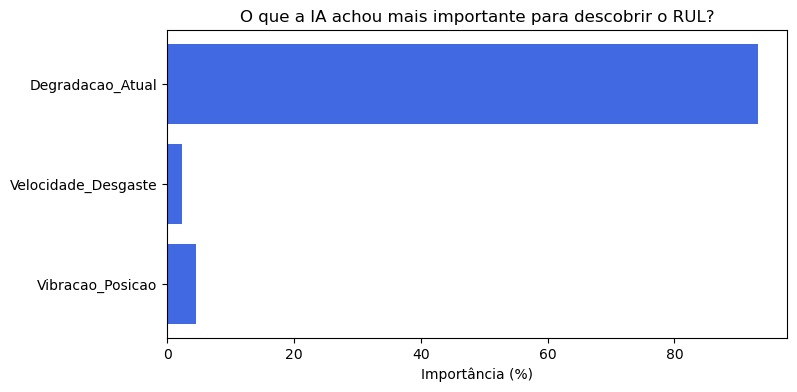

As engenharias de features (Velocidade e Vibração) ajudaram o modelo?


In [8]:
# ==========================================
# CÉLULA 6: IMPORTÂNCIA DAS VARIÁVEIS (Feature Importance)
# ==========================================
importancias = modelo_rf.feature_importances_

# Criando um gráfico de barras horizontal
plt.figure(figsize=(8, 4))
plt.barh(features, importancias * 100, color='royalblue')
plt.xlabel('Importância (%)')
plt.title('O que a IA achou mais importante para descobrir o RUL?')
plt.gca().invert_yaxis()
plt.show()

print("As engenharias de features (Velocidade e Vibração) ajudaram o modelo?")